In [3]:
from IPython.display import display, clear_output
import ipywidgets as widgets

from arcgis.features import SpatialDataFrame
from arcgis.geoenrichment import enrich
from arcgis.raster import ImageryLayer
from arcgis.geometry import Geometry
from arcgis.gis import GIS
from arcgis.mapping import create_symbol
gis = GIS('https://dbsne.maps.arcgis.com', 'jscarmazzi_DBSNE', 'gis12345')
# run_btn on_click
def running(button_object):
    
    symbol = None
    viz_map.clear_graphics()

    the_geom = Geometry(viz_map.extent)
    print(the_geom)
    print("---")
    enriched = SpatialDataFrame(enrich([the_geom], gis=gis))

    for feature in enriched.to_featureset():
        print(feature.geometry)
        symbol = create_symbol(geometry_type='polygon', 
                               cmap='Greens_r')
        viz_map.draw(feature.geometry, 
                     symbol=symbol)
# Create & Display Map
viz_map = gis.map('St Louis')
display(viz_map)

# Create Submit Button & Set on_click
run_btn = widgets.Button(
    description='Fetch Extent',
    button_style='success',
    layout=widgets.Layout(justify_content='center', margin='0px 0px 0px 10px')
)
run_btn.on_click(running)

# Handle Widget Layout
params = widgets.HBox(
    [run_btn], 
    layout=widgets.Layout(justify_content='center', margin='10px')
)
display(params)

MapView(layout=Layout(height='400px', width='100%'))

{'spatialReference': {'latestWkid': 3857, 'wkid': 102100}, 'xmin': -10078652.543921696, 'ymin': 4653211.691336008, 'xmax': -10003285.634032613, 'ymax': 4683786.502650037}
---
{'rings': [[[-90.53807623534956, 38.520454212728445], [-90.53807623534956, 38.735021954851234], [-89.86104376464733, 38.735021954851234], [-89.86104376464733, 38.520454212728445], [-90.53807623534956, 38.520454212728445]]], 'spatialReference': {'wkid': 4326, 'latestWkid': 4326}}


# Press the button, should look like this:
The whole screen should turn a solid color: if you zoom out, you should see something like this:

<img src=" 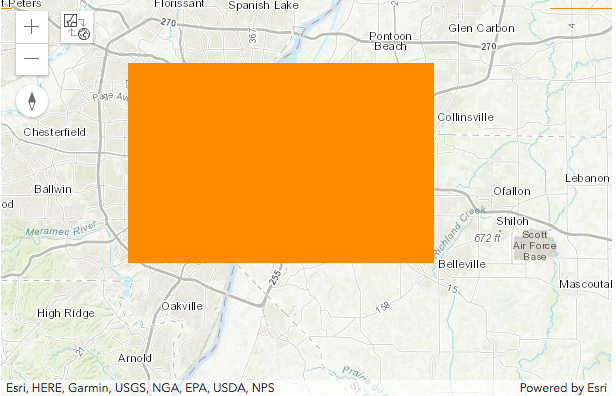">

In [4]:
viz_map._readonly_webmap_from_js

{'layers': [{'id': 'graphicsLayerId31195',
   'url': None,
   'graphics': [{'geometry': {'spatialReference': {'latestWkid': 4326,
       'wkid': 4326},
      'rings': [[[-72.48642904188986, 26.14669683070787],
        [-72.48642904188986, 40.73987910899463],
        [-45.50400716689704, 40.73987910899463],
        [-45.50400716689704, 26.14669683070787],
        [-72.48642904188986, 26.14669683070787]]]},
     'symbol': {'type': 'esriSFS',
      'color': [254, 18, 0, 255],
      'outline': {'type': 'esriSLS',
       'color': [128, 128, 128, 255],
       'width': 2,
       'style': 'esriSLSSolid'},
      'style': 'esriSFSSolid'},
     'attributes': {},
     'popupTemplate': None}]}],
 'ground': {'layers': [{'id': 'worldElevation',
    'listMode': 'show',
    'title': 'Terrain3D',
    'url': 'https://elevation3d.arcgis.com/arcgis/rest/services/WorldElevation3D/Terrain3D/ImageServer',
    'visibility': True,
    'layerType': 'ArcGISTiledElevationServiceLayer'}],
  'transparency': 0},
 'ba

In [3]:
viz_map.clear_graphics()